#0. Importing Libraries and Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score

In [2]:
path = kagglehub.dataset_download(
    "mohankrishnathalla/sleep-health-and-daily-performance-dataset"
)
df = pd.read_csv(os.path.join(path, "sleep_health_dataset.csv"))

100%|██████████| 4.07M/4.07M [00:01<00:00, 4.06MB/s]

Extracting files...


#1. EDA

In [3]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [ ]:
df.tail()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
99995,99996,44,Female,Nurse,25.9,USA,6.77,6.3,26.8,24.6,...,72,1,0,19.1,1.93,Spring,Weekend,89.4,Healthy,1
99996,99997,44,Female,Manager,30.2,India,4.90,4.1,21.6,22.3,...,80,1,0,18.6,1.44,Spring,Weekday,40.5,Mild,0
99997,99998,39,Male,Manager,29.2,Brazil,5.94,5.1,21.4,14.3,...,74,1,0,19.4,0.62,Spring,Weekday,64.8,Healthy,1
99998,99999,33,Female,Nurse,27.3,India,5.27,3.0,21.9,23.6,...,68,1,0,20.6,2.32,Winter,Weekend,40.8,Mild,0
99999,100000,30,Male,Sales,24.3,USA,6.33,4.7,14.5,25.3,...,48,0,0,21.1,-0.12,Autumn,Weekday,54.3,Mild,0


In [ ]:
df.shape

(100000, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [ ]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [ ]:
df.drop(
    ["person_id"],
    axis=1,
    inplace=True
)

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0
sleep_latency_mins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
import numpy as np
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
       'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used',
       'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs',
       'cognitive_performance_score', 'felt_rested'],
      dtype='object')

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['gender', 'occupation', 'country', 'chronotype',
       'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk'],
      dtype='object')

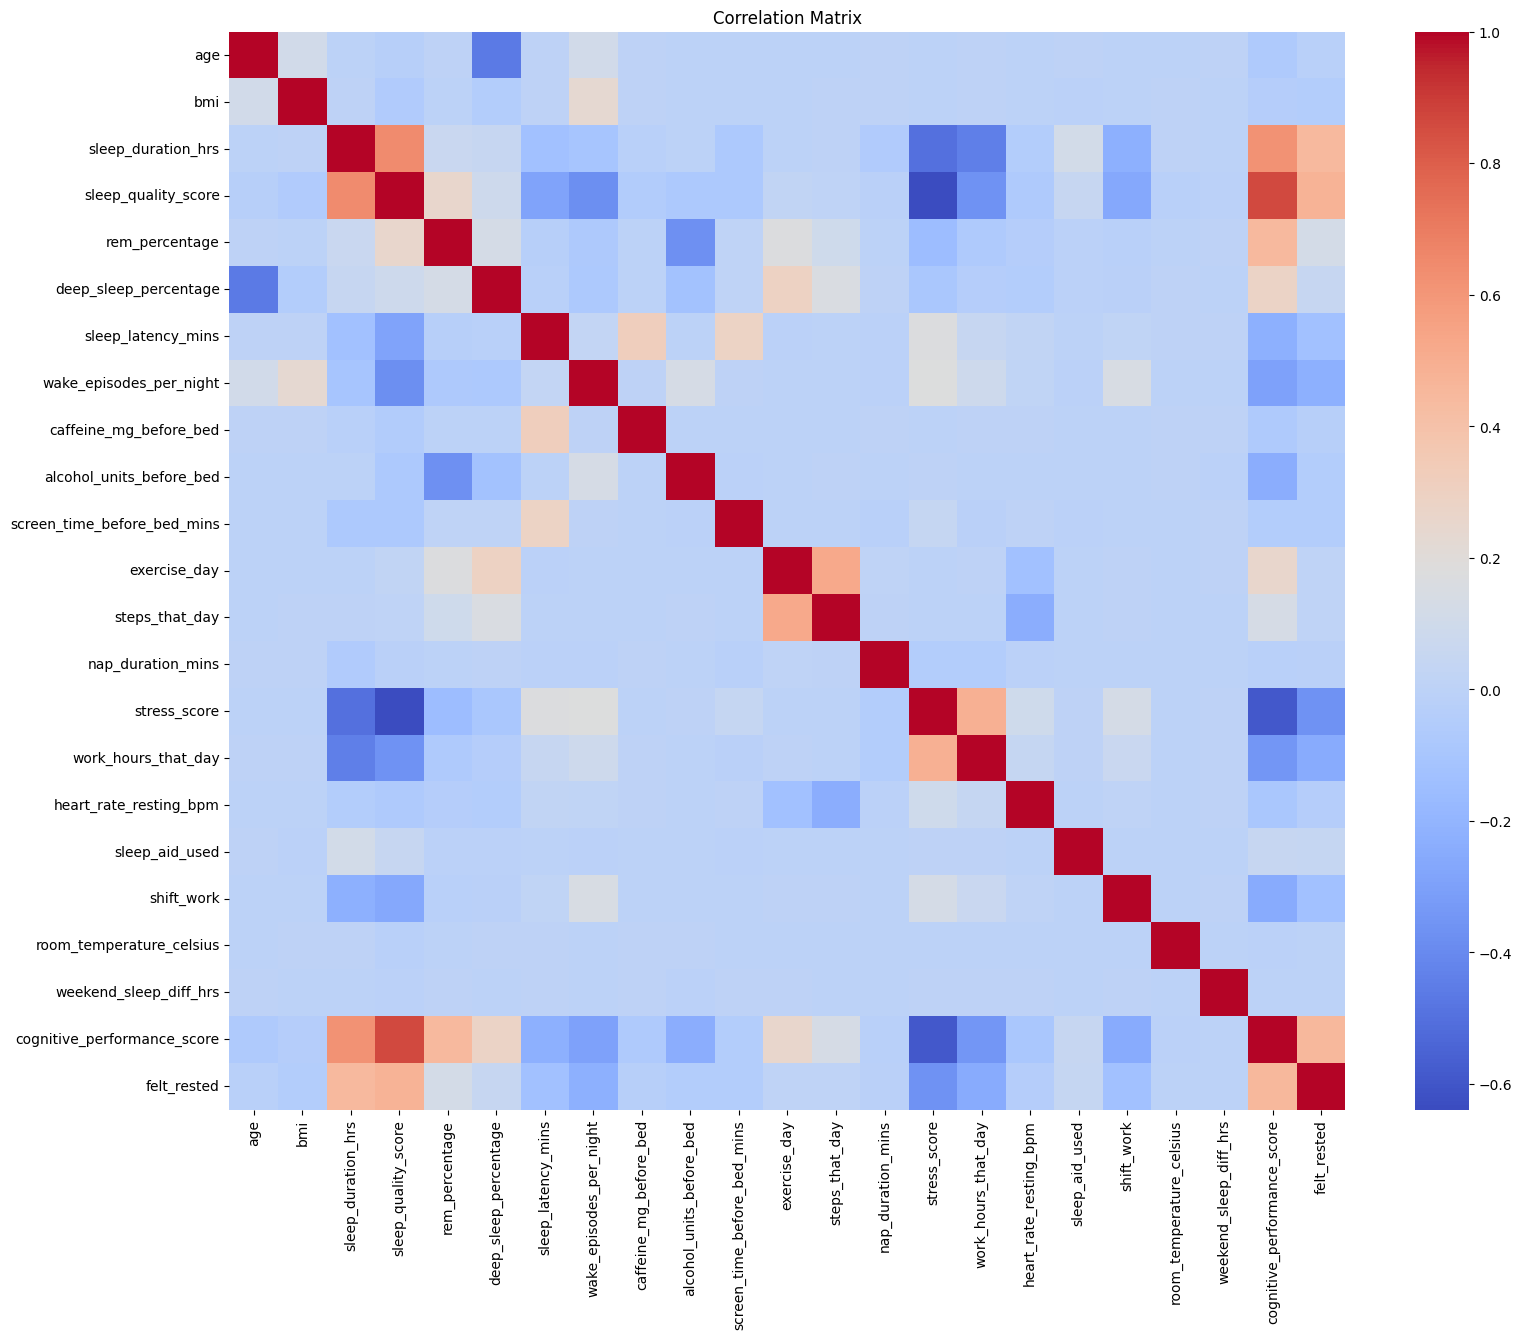

In [ ]:
plt.figure(figsize=(18,14))

sns.heatmap(
    df[numeric_cols].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:

print("=== Correlation for Sleep Quality Score ===")
print(df.corr(numeric_only=True)["sleep_quality_score"].sort_values(ascending=False))

print("\n" + "="*50 + "\n")
print("=== Correlation for Felt Rested ===")
print(df.corr(numeric_only=True)["felt_rested"].sort_values(ascending=False))

print("\n" + "="*50 + "\n")
df['sleep_disorder_num'] = df['sleep_disorder_risk'].astype('category').cat.codes

print("=== Correlation for Sleep Disorder Risk ===")
print(df.corr(numeric_only=True)["sleep_disorder_num"].sort_values(ascending=False))

=== Correlation for Sleep Quality Score ===
sleep_quality_score            1.000000
cognitive_performance_score    0.859978
sleep_duration_hrs             0.646462
felt_rested                    0.478843
rem_percentage                 0.253873
deep_sleep_percentage          0.090631
sleep_aid_used                 0.049500
exercise_day                   0.021506
steps_that_day                 0.014140
weekend_sleep_diff_hrs        -0.005765
nap_duration_mins             -0.016058
room_temperature_celsius      -0.023046
age                           -0.025463
caffeine_mg_before_bed        -0.050373
bmi                           -0.057350
heart_rate_resting_bpm        -0.066450
screen_time_before_bed_mins   -0.079158
alcohol_units_before_bed      -0.080920
shift_work                    -0.263407
sleep_latency_mins            -0.292933
work_hours_that_day           -0.368638
wake_episodes_per_night       -0.381230
stress_score                  -0.638828
Name: sleep_quality_score, dtype: fl

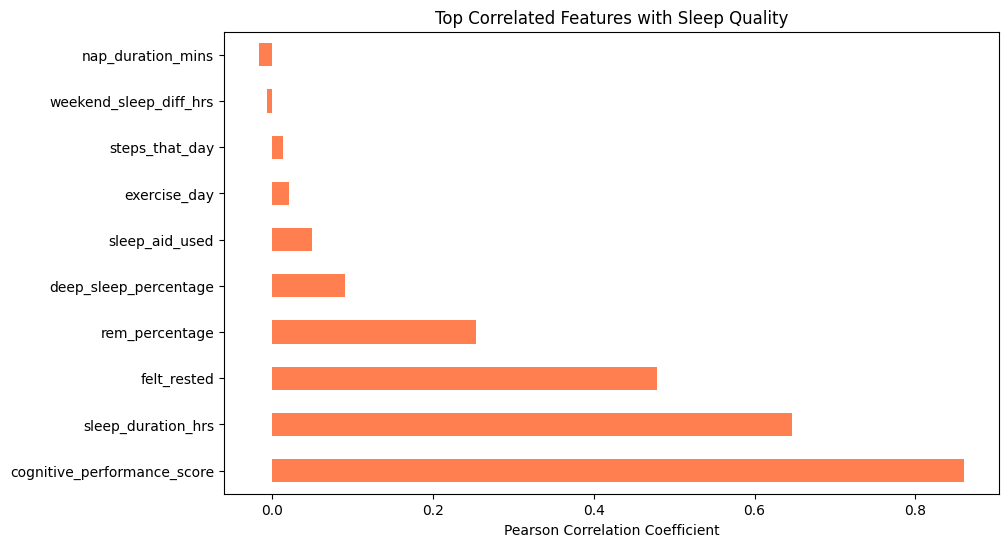

In [ ]:
target_corr = df.corr(numeric_only=True)["sleep_quality_score"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr.drop("sleep_quality_score").head(10).plot(kind="barh", color="coral")

plt.title("Top Correlated Features with Sleep Quality")
plt.xlabel("Pearson Correlation Coefficient")
plt.show()

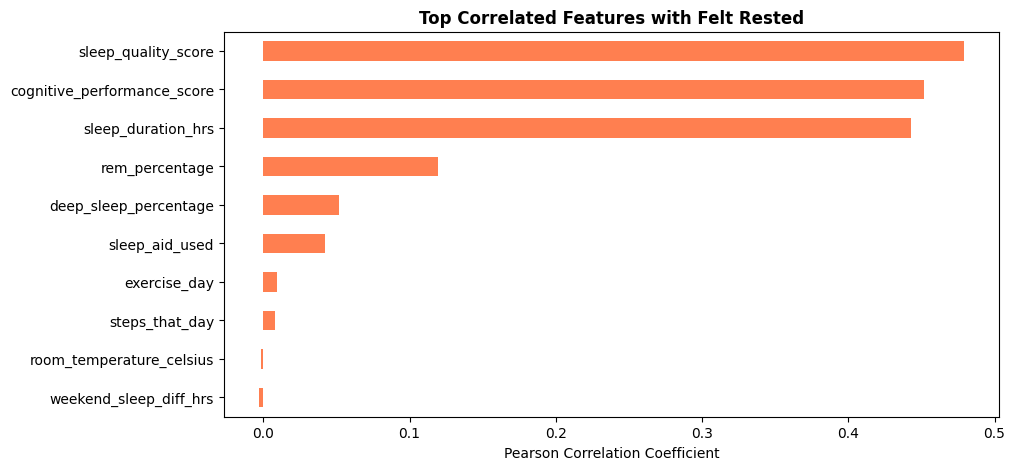

In [ ]:
corr_target2 = df.corr(numeric_only=True)["felt_rested"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_target2.drop("felt_rested").head(10).plot(kind="barh", color="coral")
plt.title("Top Correlated Features with Felt Rested", fontsize=12, fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient")
plt.gca().invert_yaxis()
plt.show()

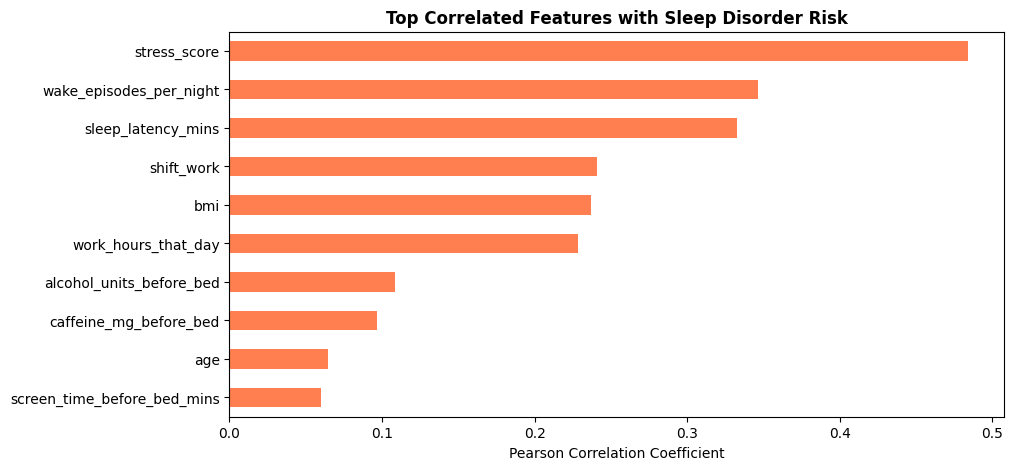

In [ ]:
df['sleep_disorder_num'] = df['sleep_disorder_risk'].astype('category').cat.codes
corr_target3 = df.corr(numeric_only=True)["sleep_disorder_num"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_target3.drop("sleep_disorder_num").head(10).plot(kind="barh", color="coral")
plt.title("Top Correlated Features with Sleep Disorder Risk", fontsize=12, fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient")
plt.gca().invert_yaxis()
plt.show()

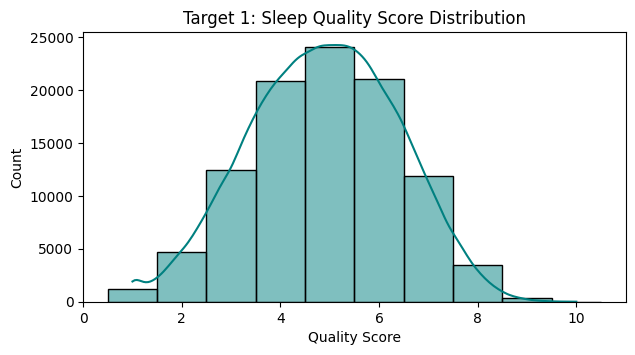

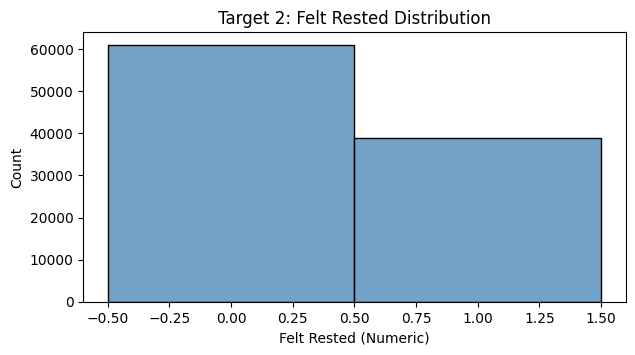

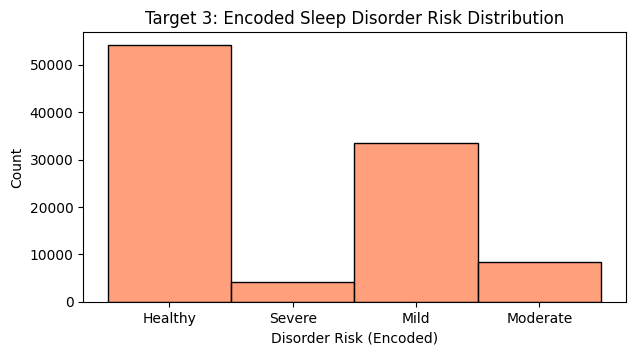

In [ ]:

plt.figure(figsize=(7, 3.5))
sns.histplot(
    df['sleep_quality_score'],
    kde=True,
    color='teal',
    discrete=True)

plt.title('Target 1: Sleep Quality Score Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(7, 3.5))
sns.histplot(
    df['felt_rested'],
    color='steelblue',
    discrete=True)
plt.title('Target 2: Felt Rested Distribution')
plt.xlabel('Felt Rested (Numeric)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(7, 3.5))
sns.histplot(
    df['sleep_disorder_risk'],
    color='coral',
    discrete=True)

plt.title('Target 3: Encoded Sleep Disorder Risk Distribution')
plt.xlabel('Disorder Risk (Encoded)')
plt.ylabel('Count')
plt.show()

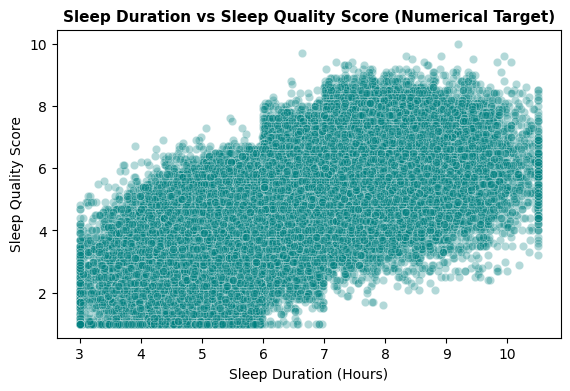

/tmp/ipykernel_838/1726628033.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


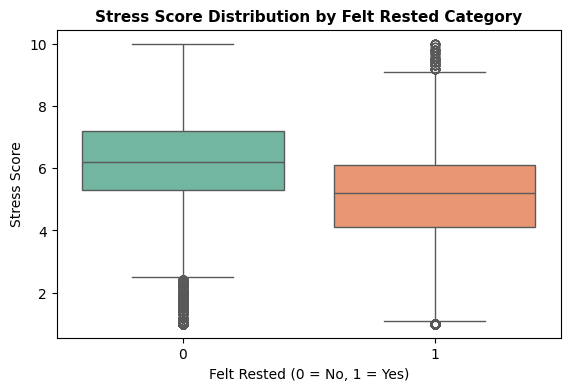

/tmp/ipykernel_838/1726628033.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


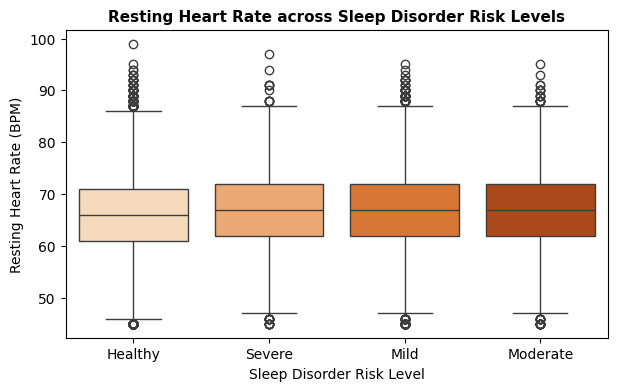

In [ ]:
plt.figure(figsize=(6.5, 4))
sns.scatterplot(
    data=df,
    x='sleep_duration_hrs',
    y='sleep_quality_score',
    alpha=0.3,
    color='teal'
)
plt.title('Sleep Duration vs Sleep Quality Score (Numerical Target)',
          fontsize=11,
          fontweight='bold')

plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Sleep Quality Score')
plt.show()

plt.figure(figsize=(6.5, 4))
sns.boxplot(
    data=df,
    x='felt_rested',
    y='stress_score',
    palette='Set2'
)
plt.title('Stress Score Distribution by Felt Rested Category',
          fontsize=11,
          fontweight='bold')

plt.xlabel('Felt Rested (0 = No, 1 = Yes)')
plt.ylabel('Stress Score')
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x='sleep_disorder_risk',
    y='heart_rate_resting_bpm',
    palette='Oranges'
)
plt.title('Resting Heart Rate across Sleep Disorder Risk Levels',
          fontsize=11,
          fontweight='bold')

plt.xlabel('Sleep Disorder Risk Level')
plt.ylabel('Resting Heart Rate (BPM)')
plt.show()




#2. Felt rested prediction

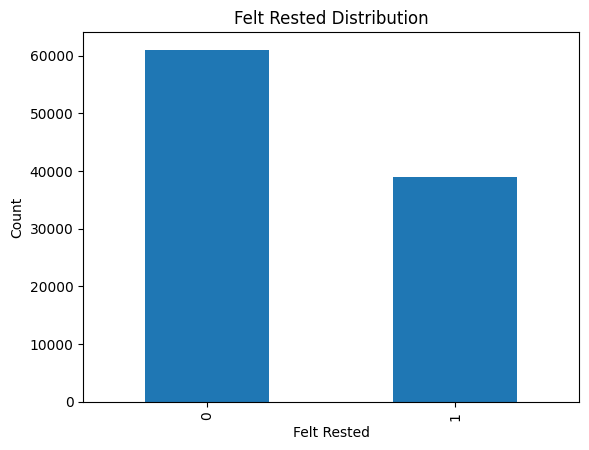

In [ ]:
df["felt_rested"].value_counts().plot(kind="bar")
plt.title("Felt Rested Distribution")
plt.xlabel("Felt Rested")
plt.ylabel("Count")
plt.show()

In [ ]:
X = df.drop(columns=["felt_rested"])
y = df["felt_rested"]
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
model.fit(X_train, y_train)
print("Model training completed! ✅")

Model training completed! ✅


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.74215
              precision    recall  f1-score   support

           0       0.77      0.81      0.79     12132
           1       0.69      0.63      0.66      7868

    accuracy                           0.74     20000
   macro avg       0.73      0.72      0.73     20000
weighted avg       0.74      0.74      0.74     20000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9866 2266]
 [2891 4977]]


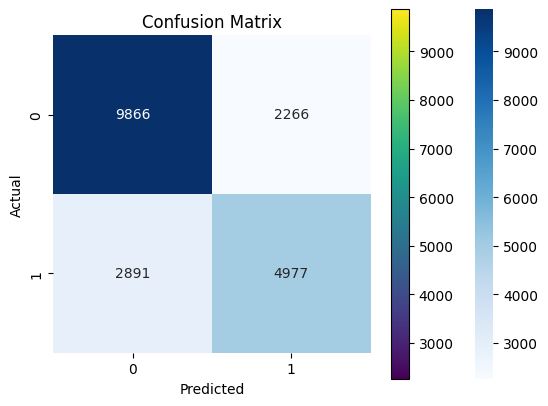

In [ ]:
plt.imshow(cm)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(10)
print(importance)

sleep_duration_hrs             0.101736
sleep_quality_score            0.092758
cognitive_performance_score    0.076251
stress_score                   0.053599
work_hours_that_day            0.040411
sleep_disorder_num             0.039559
steps_that_day                 0.037885
rem_percentage                 0.037448
weekend_sleep_diff_hrs         0.036780
bmi                            0.036766
dtype: float64


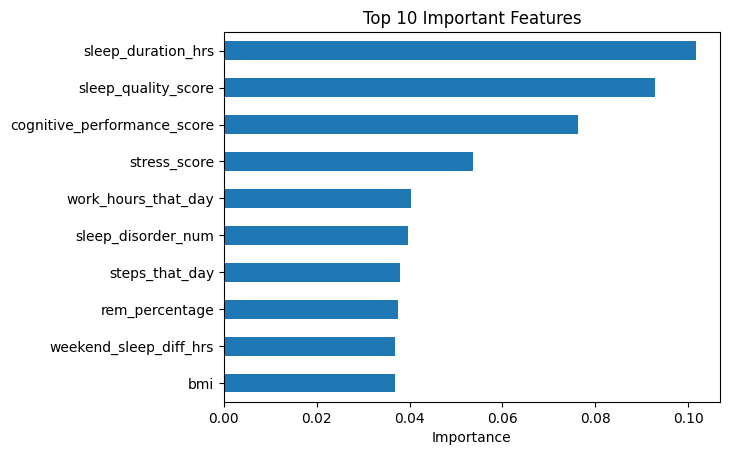

In [ ]:
importance.sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

#3. Sleep quality prediction

In [ ]:
TARGET = "sleep_quality_score"

LEAKAGE_COLUMNS = [
    TARGET,
    "felt_rested",
    "sleep_disorder_risk"
]

model_df = df.drop(columns=[c for c in LEAKAGE_COLUMNS if c in df.columns]).copy()

X = model_df
y = df[TARGET]

print("Features:")
print(list(X.columns))

print("\nTarget:")
print(TARGET)


Features:
['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_num']

Target:
sleep_quality_score


In [ ]:
numerical_columns = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


Numerical Columns:
['age', 'bmi', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score']

Categorical Columns:
['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (80000, 29)
Testing Data: (20000, 29)


In [ ]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_prediction)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_prediction))
linear_r2 = r2_score(y_test, linear_prediction)

linear_accurasy = 100 - ( (linear_mae / y_test.mean()) * 100)

print("Linear Regression completed.")
print("MAE:",linear_mae)
print("RMSE:",linear_rmse)
print("R2 Score:",linear_r2)
print("Accurasy:",linear_accurasy,"%")

Linear Regression completed.
MAE: 0.4532870154467839
RMSE: 0.5687694077154952
R2 Score: 0.8590764621375832
Accurasy: 90.71751363442823 %


In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)
tree_prediction = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_prediction)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_prediction))
tree_r2 = r2_score(y_test, tree_prediction)
tree_accurasy = 100 - ((tree_mae / y_test.mean()) * 100)
print("Decision Tree Regression completed.")

print("MAE:",tree_mae)
print("RMSE:",tree_rmse)
print("R2 Score:",tree_r2)
print("Accurasy:",tree_accurasy,"%")

Decision Tree Regression completed.
MAE: 0.5004941513604856
RMSE: 0.6278404891504715
R2 Score: 0.8282844129643543
Accurasy: 89.75079810862673 %


In [ ]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_model.fit(X_train, y_train)
forest_prediction = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_prediction)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_prediction))
forest_r2 = r2_score(y_test, forest_prediction)
forest_accurasy = 100 - ((forest_mae / y_test.mean()) * 100)

print("Random Forest Regression completed.")
print("MAE:",forest_mae)
print("RMSE:",forest_rmse)
print("R2 Score:",forest_r2)
print("Accurasy:",forest_accurasy,"%")



Random Forest Regression completed.
MAE: 0.43830861832350804
RMSE: 0.5495108029261855
R2 Score: 0.8684582701208662
Accurasy: 91.02424372449684 %


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"

    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        forest_r2
    ],
    "Accurasy": [
        linear_accurasy,
        tree_accurasy,
        forest_accurasy
    ]

})

print("==========================================")
print("Model Comparison")
print("==========================================")

results


Model Comparison


,Model,MAE,RMSE,R2 Score,Accurasy
0,Linear Regression,0.453287,0.568769,0.859076,90.717514
1,Decision Tree,0.500494,0.627840,0.828284,89.750798
2,Random Forest,0.438309,0.549511,0.868458,91.024244


In [ ]:
best_model_index = results["Accurasy"].idxmax()
best_model_name = results.loc[best_model_index, "Model"]

print("Best Model and Accurasy:")
print(best_model_name)

Best Model and Accurasy:
Random Forest


In [ ]:
accuracies =[
     linear_accurasy,
     tree_accurasy,
     forest_accurasy
]

models =[
    "Linear Regression",
    "Decision tree",
    "Random Forest"
]

print("Accuracy Results:")
print("Linear Regression:",linear_accurasy,"%")
print("Decision tree:",tree_accurasy,"%")
print("Random Forest:",forest_accurasy,"%")

Accuracy Results:
Linear Regression: 90.71751363442823 %
Decision tree: 89.75079810862673 %
Random Forest: 91.02424372449684 %


Accuracy Values:
Linear Regression: 90.71751363442823 %
Decision Tree: 89.75079810862673 %
Random Forest: 91.02424372449684 %


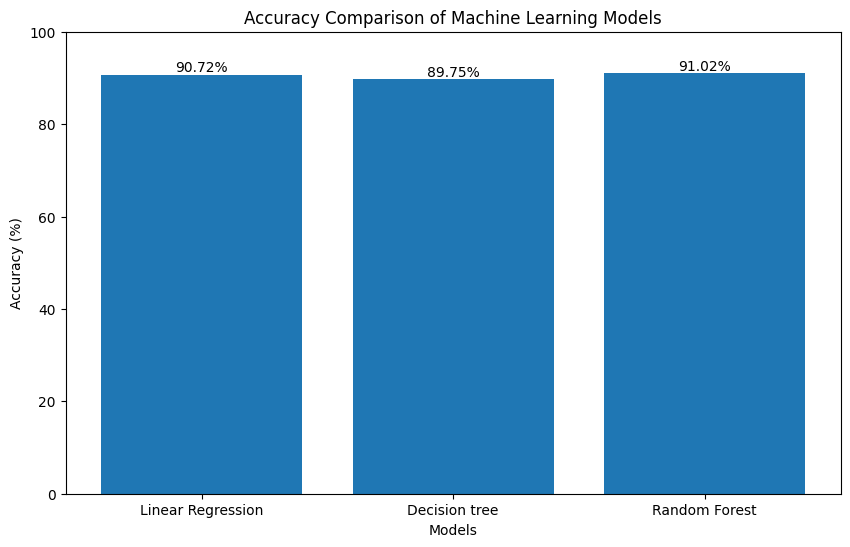

In [ ]:

print("Accuracy Values:")
print("Linear Regression:", accuracies[0], "%")
print("Decision Tree:", accuracies[1], "%")
print("Random Forest:", accuracies[2], "%")

plt.figure(figsize=(10, 6))

bars = plt.bar(
    models,
    accuracies
)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Machine Learning Models")

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{accuracy:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 100)
plt.show()

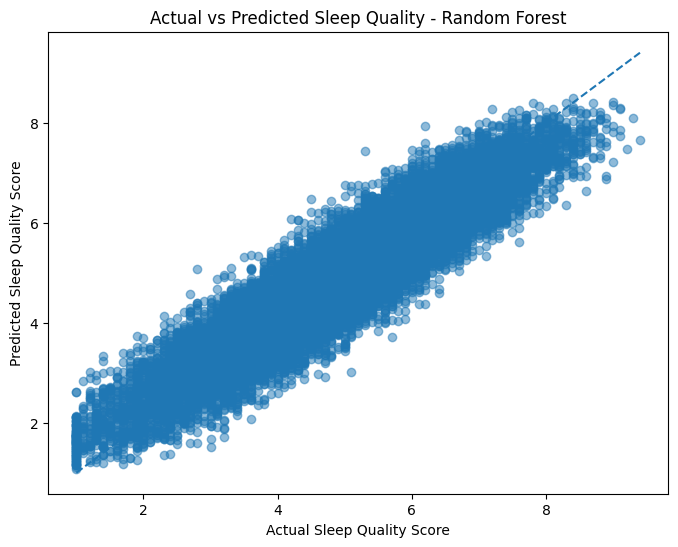

In [ ]:
predictions_by_model = {
    "Linear Regression": linear_prediction,
    "Decision Tree": tree_prediction,
    "Random Forest": forest_prediction
}

best_prediction = predictions_by_model[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_prediction, alpha=0.5)

min_value = min(y_test.min(), best_prediction.min())
max_value = max(y_test.max(), best_prediction.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual Sleep Quality Score")
plt.ylabel("Predicted Sleep Quality Score")
plt.title(f"Actual vs Predicted Sleep Quality - {best_model_name}")
plt.show()


In [ ]:
new_person = pd.DataFrame({
    "age": [25],
    "gender": ["Male"],
    "occupation": ["Student"],
    "bmi": [22.5],
    "country": ["Egypt"],
    "sleep_duration_hrs": [7.5],
    "rem_percentage": [20],
    "deep_sleep_percentage": [22],
    "sleep_latency_mins": [15],
    "wake_episodes_per_night": [1],
    "caffeine_mg_before_bed": [50],
    "alcohol_units_before_bed": [0],
    "screen_time_before_bed_mins": [30],
    "exercise_day": [1],
    "steps_that_day": [8000],
    "nap_duration_mins": [20],
    "stress_score": [3],
    "work_hours_that_day": [6],
    "chronotype": ["Intermediate"],
    "mental_health_condition": ["None"],
    "heart_rate_resting_bpm": [70],
    "sleep_aid_used": [0],
    "shift_work": [0],
    "room_temperature_celsius": [22],
    "weekend_sleep_diff_hrs": [1],
    "season": ["Summer"],
    "day_type": ["Weekday"],
    "cognitive_performance_score": [80],
    "felt_rested": [1]
})

new_person = new_person.reindex(columns=X.columns)

predicted_sleep_quality = forest_model.predict(new_person)

print("==========================================")
print("Prediction for New Person")
print("==========================================")
print("Predicted Sleep Quality Score:", predicted_sleep_quality[0])


Prediction for New Person
Predicted Sleep Quality Score: 6.110646350352895


#4. Sleep Disorder Prediction

In [ ]:
X = df.drop(columns=["sleep_disorder_risk", "sleep_disorder_num"])
y = df["sleep_disorder_risk"]
X = pd.get_dummies(X, drop_first=True)
X.head()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80000, 59)
X_test shape: (20000, 59)
y_train shape: (80000,)
y_test shape: (20000,)


In [ ]:
dt_param_grid = {"criterion": ["gini","entropy"],

    "max_depth": [3,5,10,None],

    "min_samples_split": [2,5,10],

    "min_samples_leaf": [1,2,5]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
dt_grid.fit(
    X_train,
    y_train
)
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [ ]:
decision_tree = DecisionTreeClassifier(
    criterion = "entropy",
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 10,
    random_state = 42
)

decision_tree.fit(
    X_train,
    y_train
)
y_pred_dt = decision_tree.predict(X_test)
dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)


In [ ]:
print("Decision Tree Accuracy:", f"{dt_accuracy:.4f}")
print(classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_
    ))

Decision Tree Accuracy: 0.9015
              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97     10831
        Mild       0.88      0.89      0.88      6696
    Moderate       0.62      0.58      0.60      1660
      Severe       0.75      0.71      0.73       813

    accuracy                           0.90     20000
   macro avg       0.80      0.79      0.79     20000
weighted avg       0.90      0.90      0.90     20000



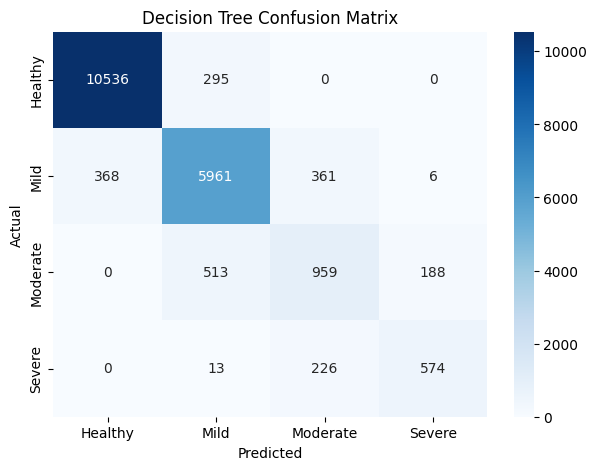

In [ ]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

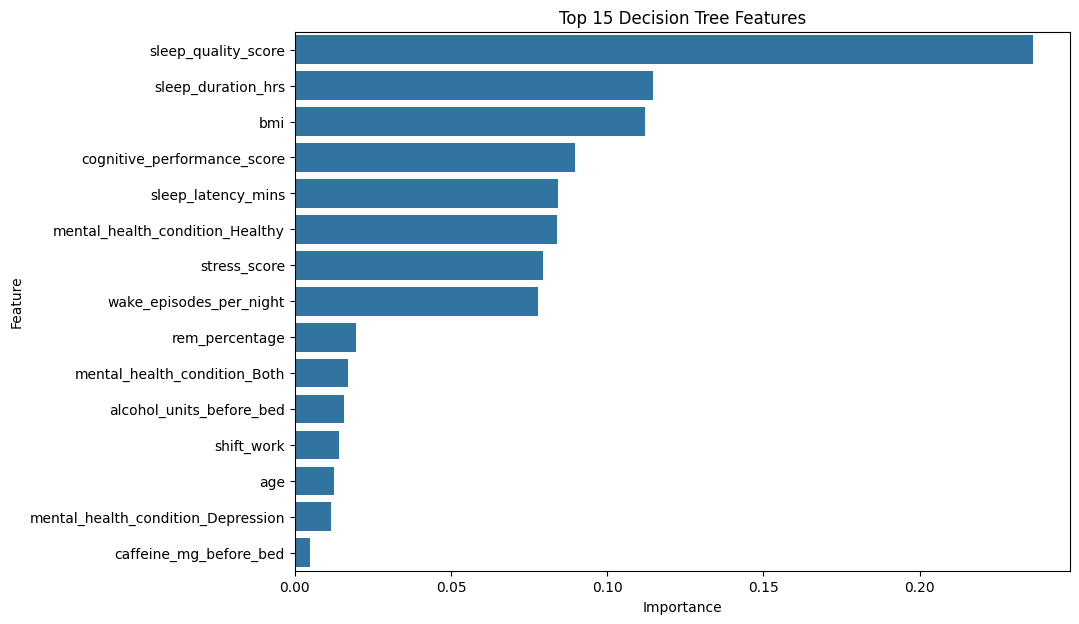

In [ ]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=dt_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Decision Tree Features")
plt.show()

In [ ]:
dt_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})

dt_comparison["Actual"] = label_encoder.inverse_transform(dt_comparison["Actual"])
dt_comparison["Predicted"] = label_encoder.inverse_transform(dt_comparison["Predicted"])

dt_comparison["Result"] = np.where(
    dt_comparison["Actual"] == dt_comparison["Predicted"],
    "Correct",
    "Incorrect"
)

dt_comparison.head(15)

,Actual,Predicted,Result
0,Healthy,Healthy,Correct
1,Mild,Mild,Correct
2,Healthy,Mild,Incorrect
3,Healthy,Healthy,Correct
4,Healthy,Healthy,Correct
5,Mild,Mild,Correct
6,Healthy,Healthy,Correct
7,Mild,Mild,Correct
8,Healthy,Healthy,Correct
9,Mild,Mild,Correct


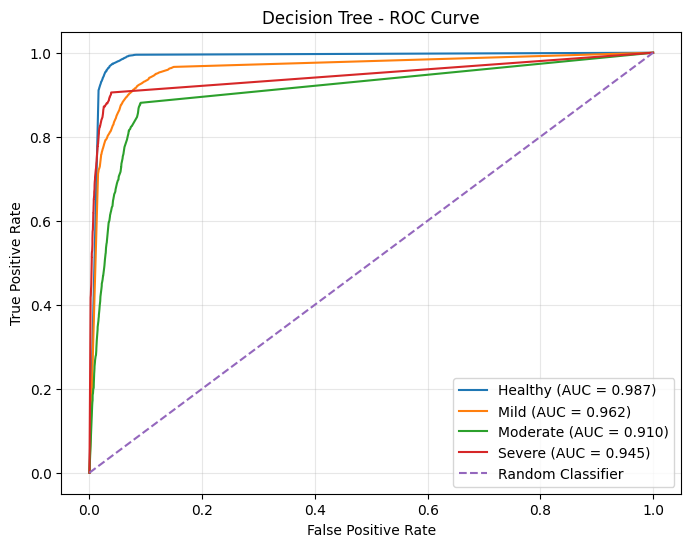

In [ ]:
y_score = decision_tree.predict_proba(X_test)

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)
y_pred_rf = random_forest.predict(X_test)
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

In [ ]:
print("Random Forest Accuracy:",f"{rf_accuracy:.4f}")

print(classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_
    ))

Random Forest Accuracy: 0.8948
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96     10831
        Mild       0.84      0.91      0.87      6696
    Moderate       0.68      0.47      0.56      1660
      Severe       0.85      0.68      0.75       813

    accuracy                           0.89     20000
   macro avg       0.83      0.76      0.79     20000
weighted avg       0.89      0.89      0.89     20000



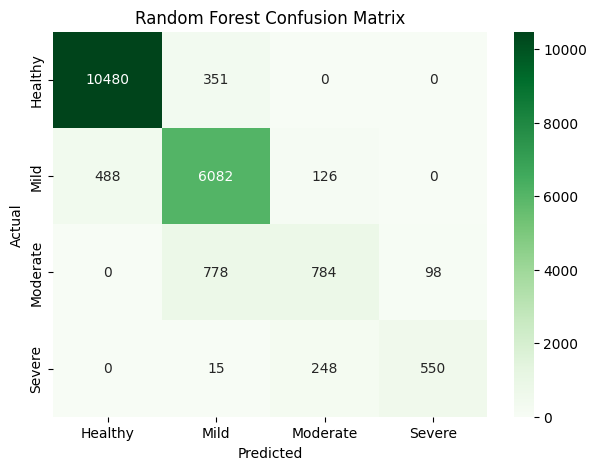

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

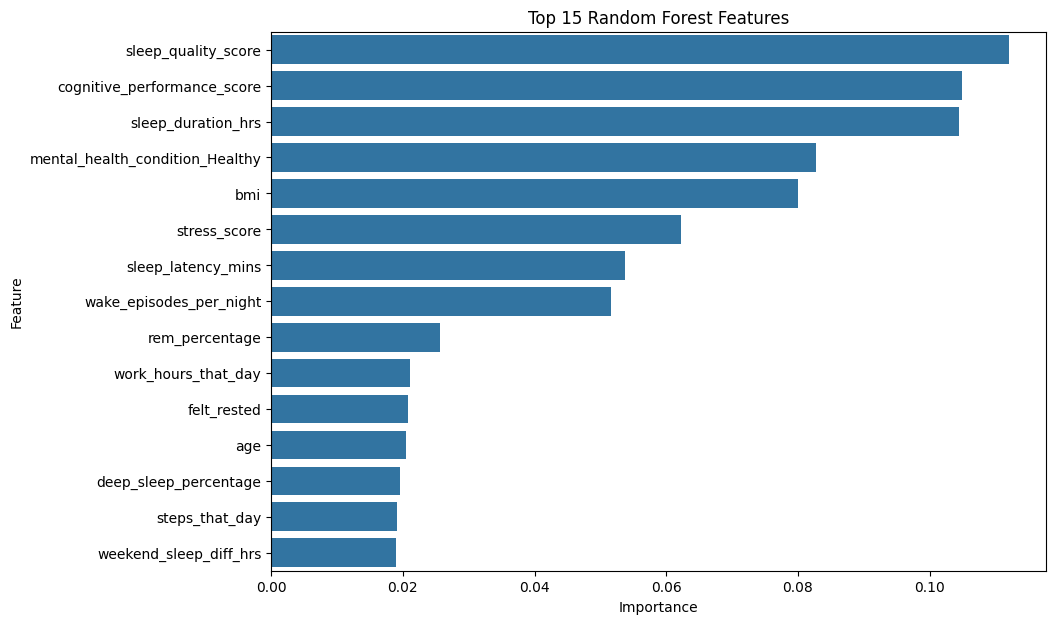

In [ ]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Features"
)

plt.show()

In [ ]:
rf_comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

rf_comparison["Actual"] = label_encoder.inverse_transform(rf_comparison["Actual"])
rf_comparison["Predicted"] = label_encoder.inverse_transform(rf_comparison["Predicted"])

rf_comparison["Result"] = np.where(
    rf_comparison["Actual"] == rf_comparison["Predicted"],
    "Correct",
    "Incorrect"
)

rf_comparison.head(15)

,Actual,Predicted,Result
0,Healthy,Healthy,Correct
1,Mild,Mild,Correct
2,Healthy,Mild,Incorrect
3,Healthy,Healthy,Correct
4,Healthy,Healthy,Correct
5,Mild,Mild,Correct
6,Healthy,Healthy,Correct
7,Mild,Mild,Correct
8,Healthy,Healthy,Correct
9,Mild,Mild,Correct


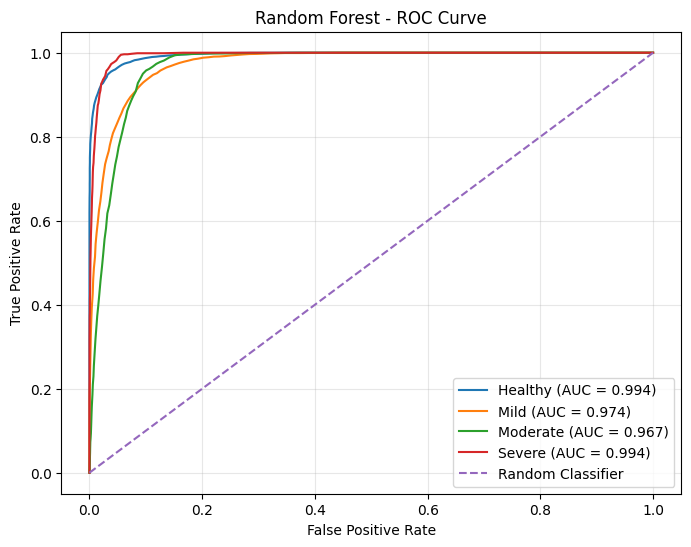

In [ ]:
y_score = random_forest.predict_proba(X_test)

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(label_encoder.classes_))
)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
results = {
    "Decision Tree": {
        "Accuracy": accuracy_score(
            y_test,
            y_pred_dt
        ),

        "Precision": precision_score(
            y_test,
            y_pred_dt,
            average="weighted"
        ),

        "Recall": recall_score(
            y_test,
            y_pred_dt,
            average="weighted"
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred_dt,
            average="weighted"
        )
    },

    "Random Forest": {
        "Accuracy": accuracy_score(
            y_test,
            y_pred_rf
        ),

        "Precision": precision_score(
            y_test,
            y_pred_rf,
            average="weighted"
        ),

        "Recall": recall_score(
            y_test,
            y_pred_rf,
            average="weighted"
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred_rf,
            average="weighted"
        )
    }
}
results_df = pd.DataFrame(results).T

print(results_df)

               Accuracy  Precision  Recall  F1 Score
Decision Tree    0.9015   0.899411  0.9015  0.900351
Random Forest    0.8948   0.889946  0.8948  0.890019


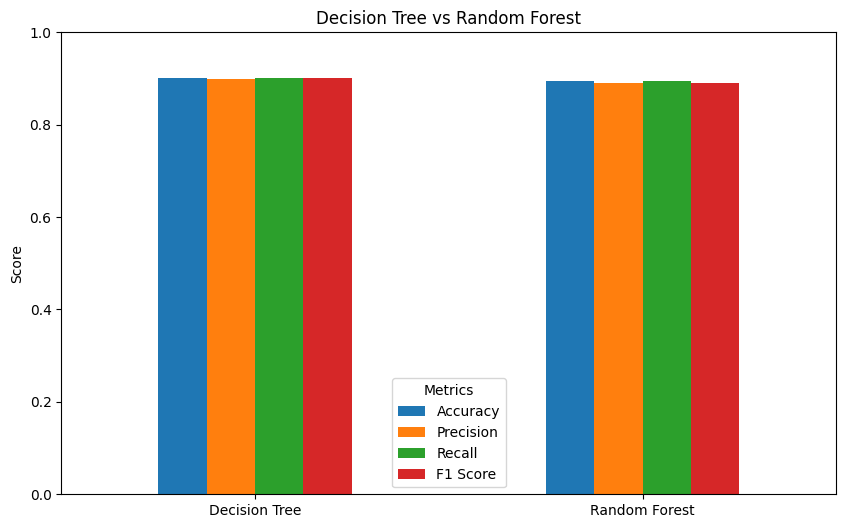

In [ ]:
results_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Decision Tree vs Random Forest")

plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(title="Metrics")

plt.show()